## Overview

This notebook provides a comprehensive demonstration of several baseline algorithms used in First-Price Auction (FPA) and VCG (Vickrey–Clarke–Groves) auction scenarios. We showcase both individual performances and comparative analyses of the following algorithms:

1. ALM
2. TA-PID
3. M-PID
4. Mystique
5. BROI

## Purpose

The main objectives of this notebook are:

1. To illustrate the implementation and behavior of each baseline algorithm
2. To compare the performance of these algorithms

Feel free to add your own bidding algorithms to our benchmark 😊


# Baselines comparison

In [1]:
import sys
sys.path.append("../")

%load_ext autoreload
%autoreload 2
    
import pandas as pd
import numpy as np
import optuna
import pickle
import matplotlib.pyplot as plt

from functools import partial

from simulator.simulation.modules import Campaign
from simulator.simulation.utils_visualization import data_prep_vis, plot_history_article
from simulator.simulation.simulate import simulate_campaign
from simulator.validation.check_results import autobidder_check

# import baselines:
from simulator.model.linear_bidder import LinearBidder
from simulator.model.ta_pid import TAPIDBidder
from simulator.model.m_pid import MPIDBidder
from simulator.model.mystique import Mystique
from simulator.model.broi_bidder import BROI
from simulator.model.traffic import Traffic
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', None)

# Load data

In [2]:
auction_mode = 'FPA' # you may also choose the 'VCG' mode

# data paths
campaigns_path = f"../data/{auction_mode.lower()}/campaigns_{auction_mode.lower()}_filtered_train_final.csv"
stats_path = f"../data/{auction_mode.lower()}/stats_{auction_mode.lower()}_filtered_train_final.csv"

In [3]:
campaign_df = pd.read_csv(campaigns_path)
stats_df = pd.read_csv(stats_path)

In [4]:
campaign_df.sample(1)

,Unnamed: 0,campaign_id,loc_id,item_id,campaign_start_date,campaign_start,campaign_end,auction_budget,microcat_ext,logical_category,region_id,campaign_end_date
964,7855,74162867,631430,1868898500,1986-10-14,529646876,529733276,57.6,734,3.9,631080,1986-10-15


In [5]:
stats_df.sample(3)

,Unnamed: 0,campaign_id,period,item_id,contact_price_bin,AuctionVisibilitySurplus,AuctionClicksSurplus,AuctionContactsSurplus,AuctionWinBidSurplus,CTRPredicts,CRPredicts,AuctionCount,x_platfrom_num,platform_p
1106006,3906718,74402240,529660800,2514863400,44.0,0.585096,0.025151,0.002181,22.00,0.013847,0.100231,4,NaN,NaN
1447583,8207335,73400264,529588800,4060730100,20.0,0.138706,0.132876,0.013535,1.37,0.291477,0.177427,3,NaN,NaN
215134,719817,74036909,529671600,3478576900,38.0,2.615663,0.774079,0.046350,234.36,0.090653,0.065189,16,NaN,NaN


# One campaign's example

In [6]:
campaign_data = campaign_df.sample(1).iloc[0]
campaign_stats = stats_df[stats_df.campaign_id == campaign_data["campaign_id"]].copy()
print(campaign_data.shape, campaign_stats.shape)

(12,) (1805, 14)


## Linear Bidder

In [16]:
campaign_example = Campaign(
    item_id= campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  120.0
Length hours  48


In [17]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=LinearBidder(),
    stats_file=campaign_stats,
    auction_mode=auction_mode
)

[simulate_campaign] ВХОД: campaign_id=74191055 balance=120.00 initial_balance=120.00 clicks=0.00 curr_time=529649606


In [18]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=LinearBidder(),
    stats_file=campaign_stats,
    auction_mode=auction_mode
)

[simulate_campaign] ВХОД: campaign_id=74191055 balance=0.00 initial_balance=120.00 clicks=153.25 curr_time=529819200
[simulate_campaign] !!! ОШИБКА: balance≈0 при initial_balance>0 — campaign уже был использован, повторный запуск с тем же объектом даст неверный результат !!!


In [15]:
df = simulation_history.to_data_frame()
viz_data_linear = data_prep_vis(df)
df.head(2)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-14 08:00:00,529650000,529649606,529822406,74191055,119.168474,120.0,1.718358,0.023098,36.000000,654070,653700,4.28,3726,529646400,0,0,0.831526,1.718358,0.009208,0.009208,19.654938,0.483907
1,1986-10-14 09:00:00,529653600,529649606,529822406,74191055,119.130133,120.0,1.781642,0.023807,54.063606,654070,653700,4.28,3726,529650000,0,0,0.038342,0.063283,0.011870,0.021078,21.885296,0.605878


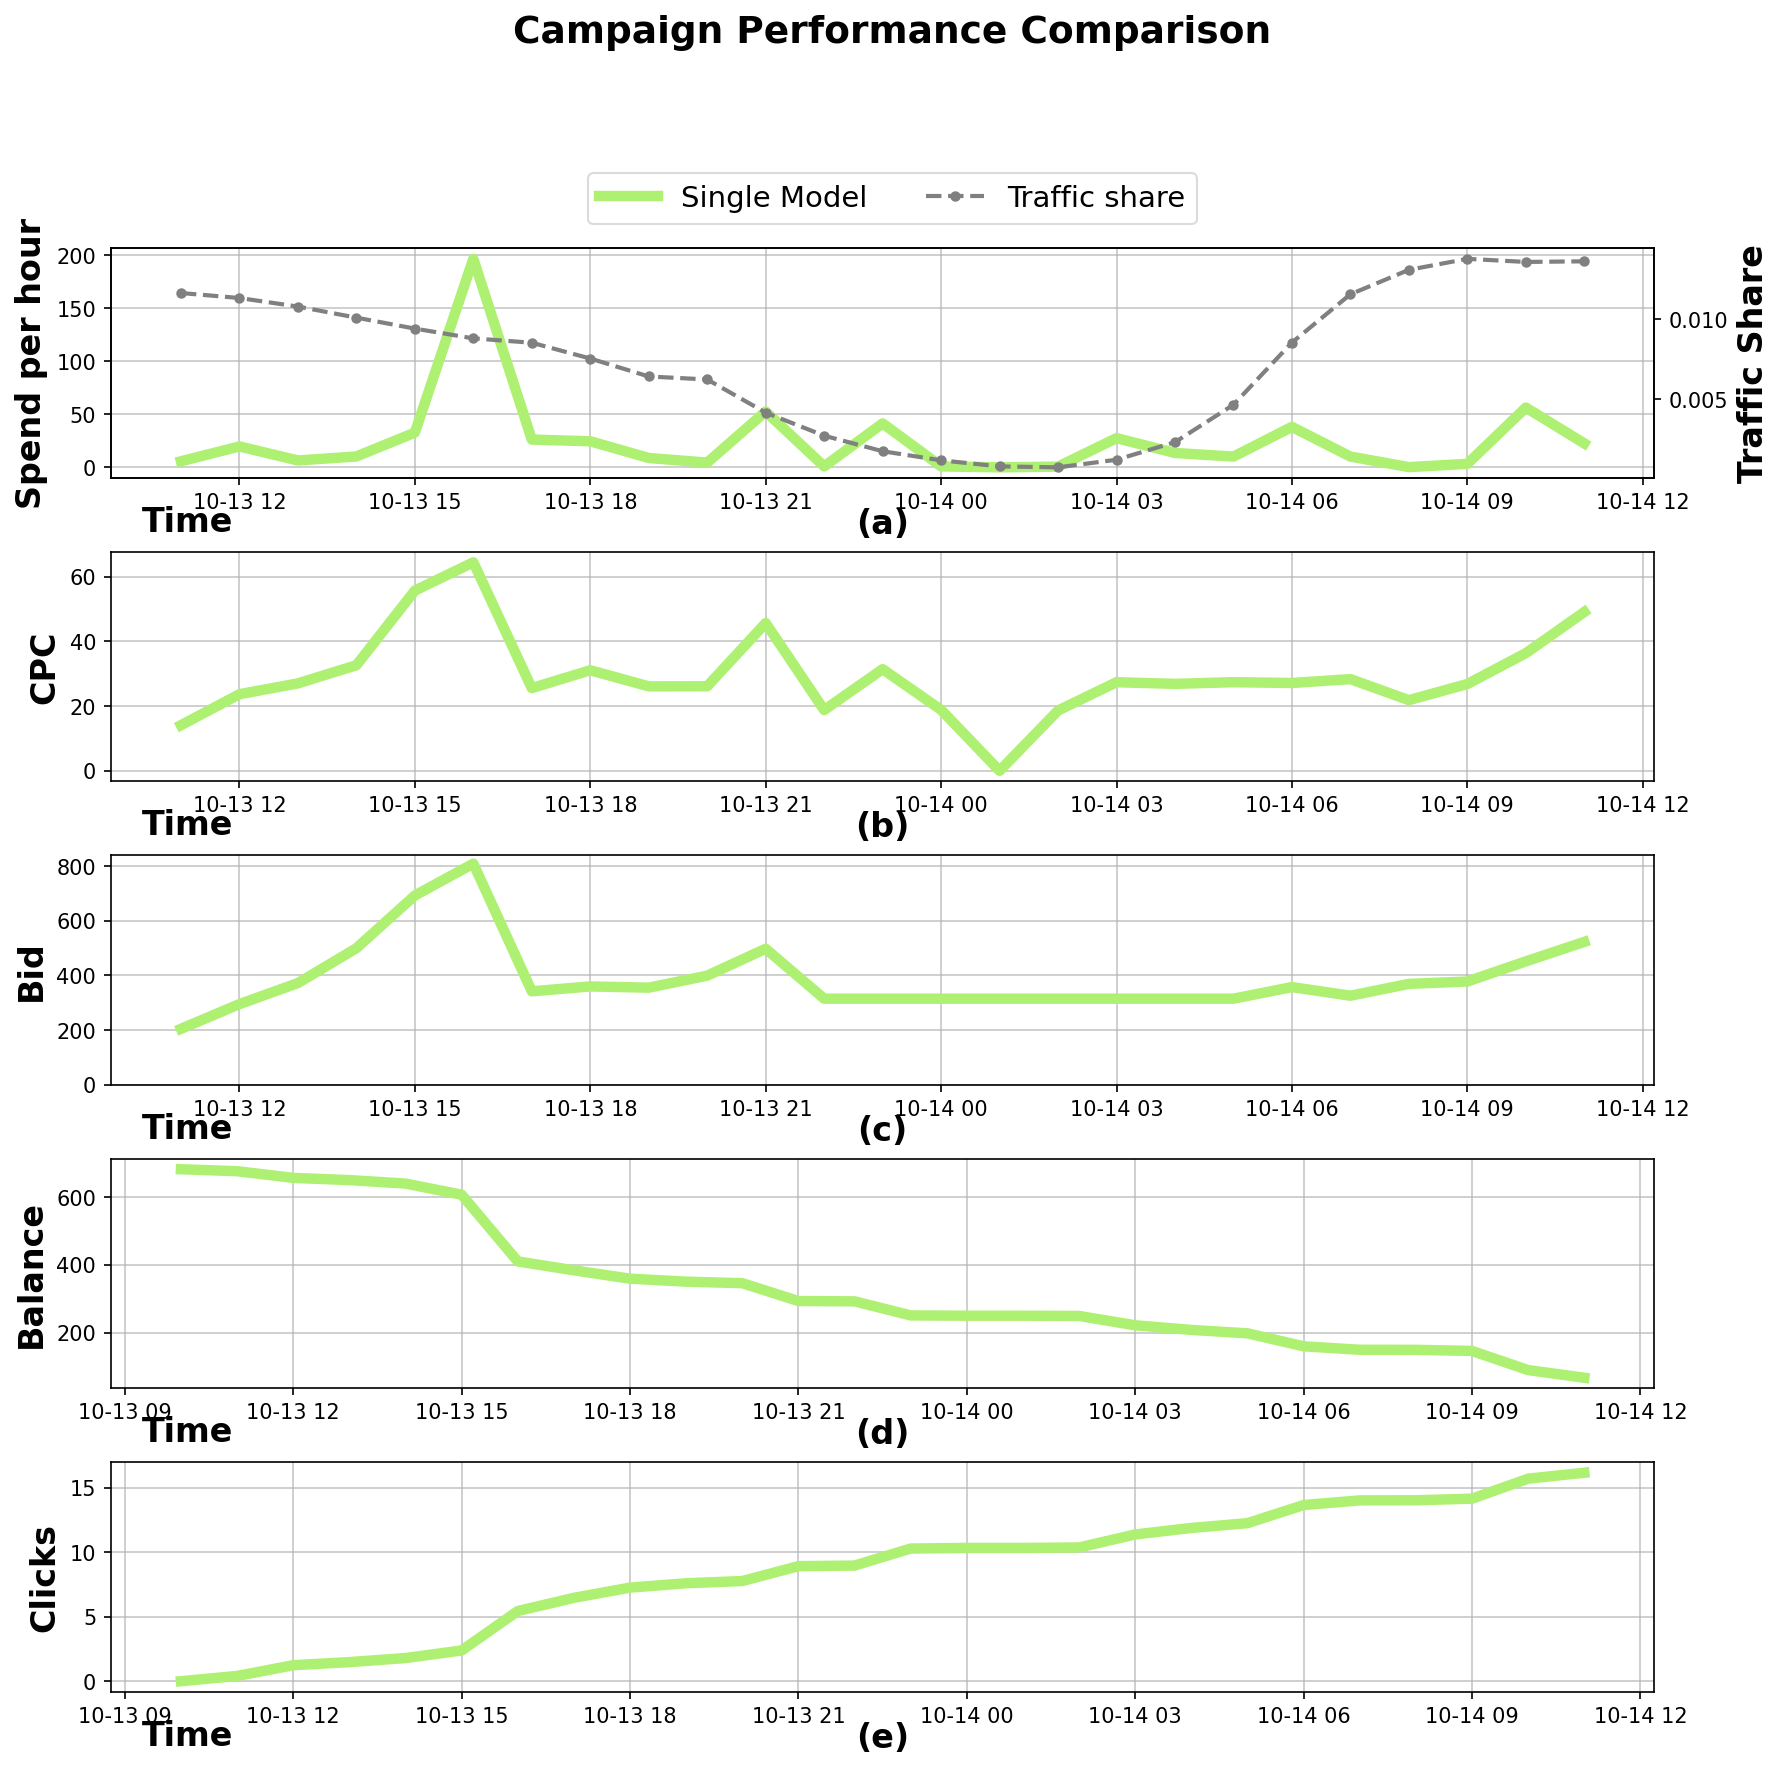

In [13]:
fig = plot_history_article(viz_data_linear)

### BROI

In [14]:
campaign_example = Campaign(
    item_id= campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  681.6
Length hours  24


In [15]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=BROI(),
    stats_file=campaign_stats,
    auction_mode=auction_mode
)

In [16]:
df = simulation_history.to_data_frame()
viz_data_broi = data_prep_vis(df)
df.head(2)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-13 11:00:00,529574400,529572969,529659369,72791422,681.6,681.6,0.0,0.0,6.191736,641780,641470,1.2,573,529570800,0,0,0.0,0.0,0.011620,0.011620,10.0,0.0
1,1986-10-13 12:00:00,529578000,529572969,529659369,72791422,681.6,681.6,0.0,0.0,6.191736,641780,641470,1.2,573,529574400,0,0,0.0,0.0,0.011307,0.022927,10.0,0.0


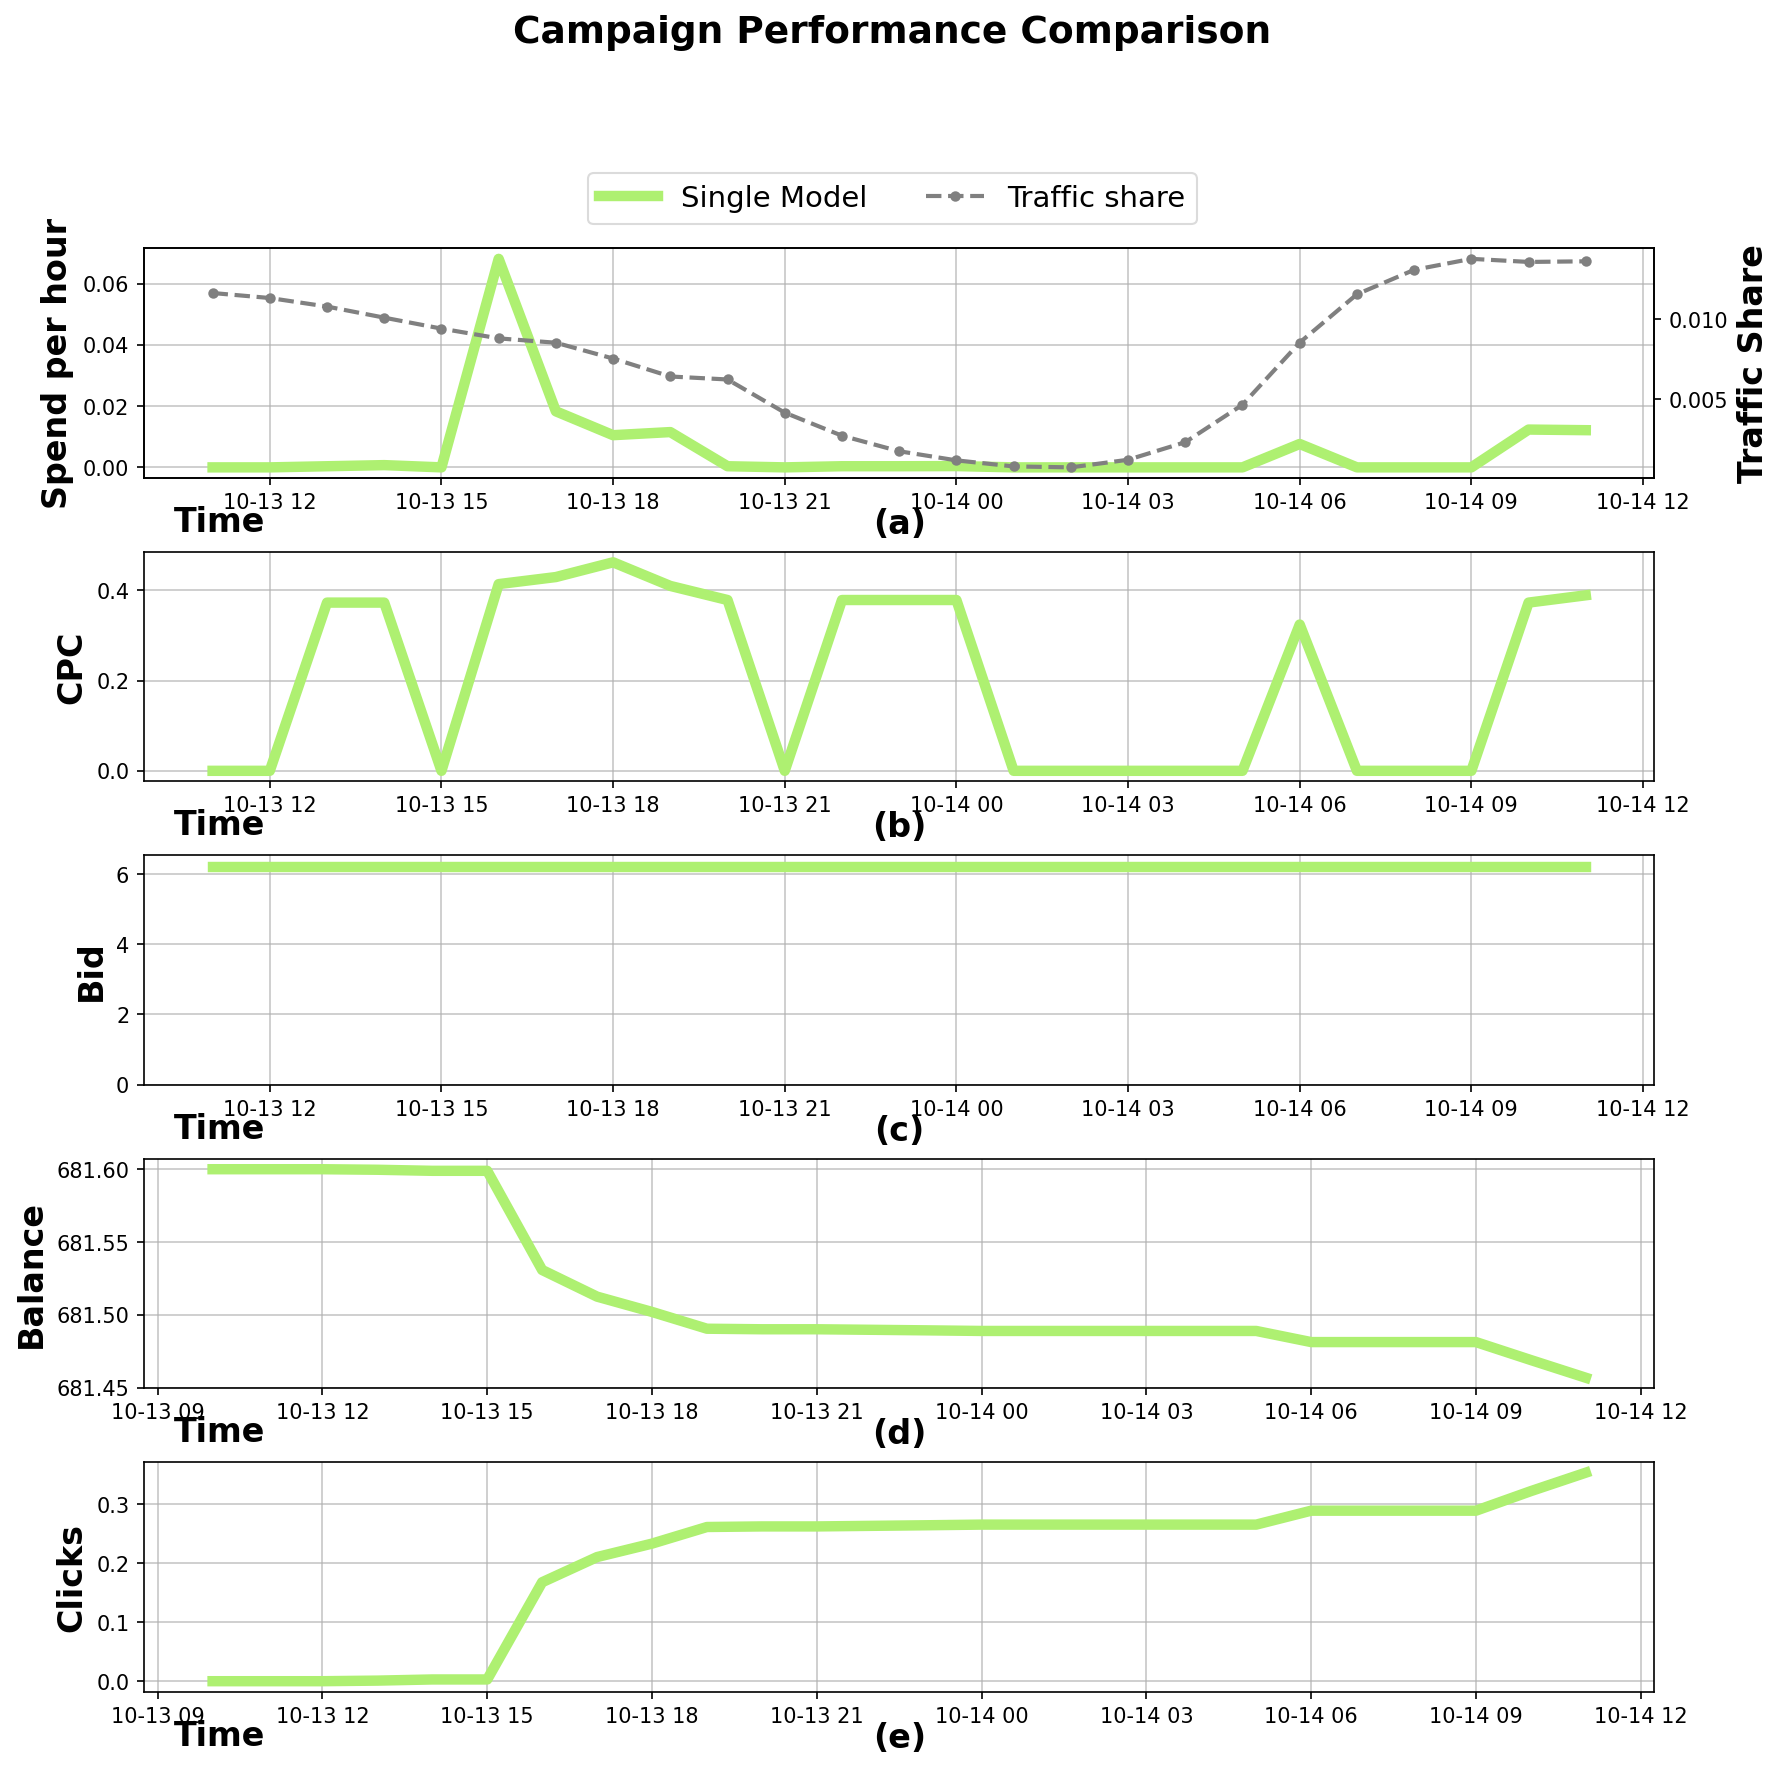

In [17]:
fig = plot_history_article(viz_data_broi)

## TA-PID Bidder

In [18]:
# refreshing Campaign
campaign_example = Campaign(
    item_id=campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  681.6
Length hours  24


In [19]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=TAPIDBidder(),
    stats_file=campaign_stats,
    auction_mode=auction_mode
)

In [20]:
df = simulation_history.to_data_frame()
viz_data_ta_pid = data_prep_vis(df)
df.head(2)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-13 11:00:00,529574400,529572969,529659369,72791422,674.313929,681.6,0.420497,0.028891,252.192,641780,641470,1.2,573,529570800,0,0,7.286071,0.420497,0.011620,0.011620,30.332073,17.327301
1,1986-10-13 12:00:00,529578000,529572969,529659369,72791422,660.952511,681.6,1.097429,0.081872,252.192,641780,641470,1.2,573,529574400,0,0,13.361419,0.676932,0.011307,0.022927,30.332073,19.738187


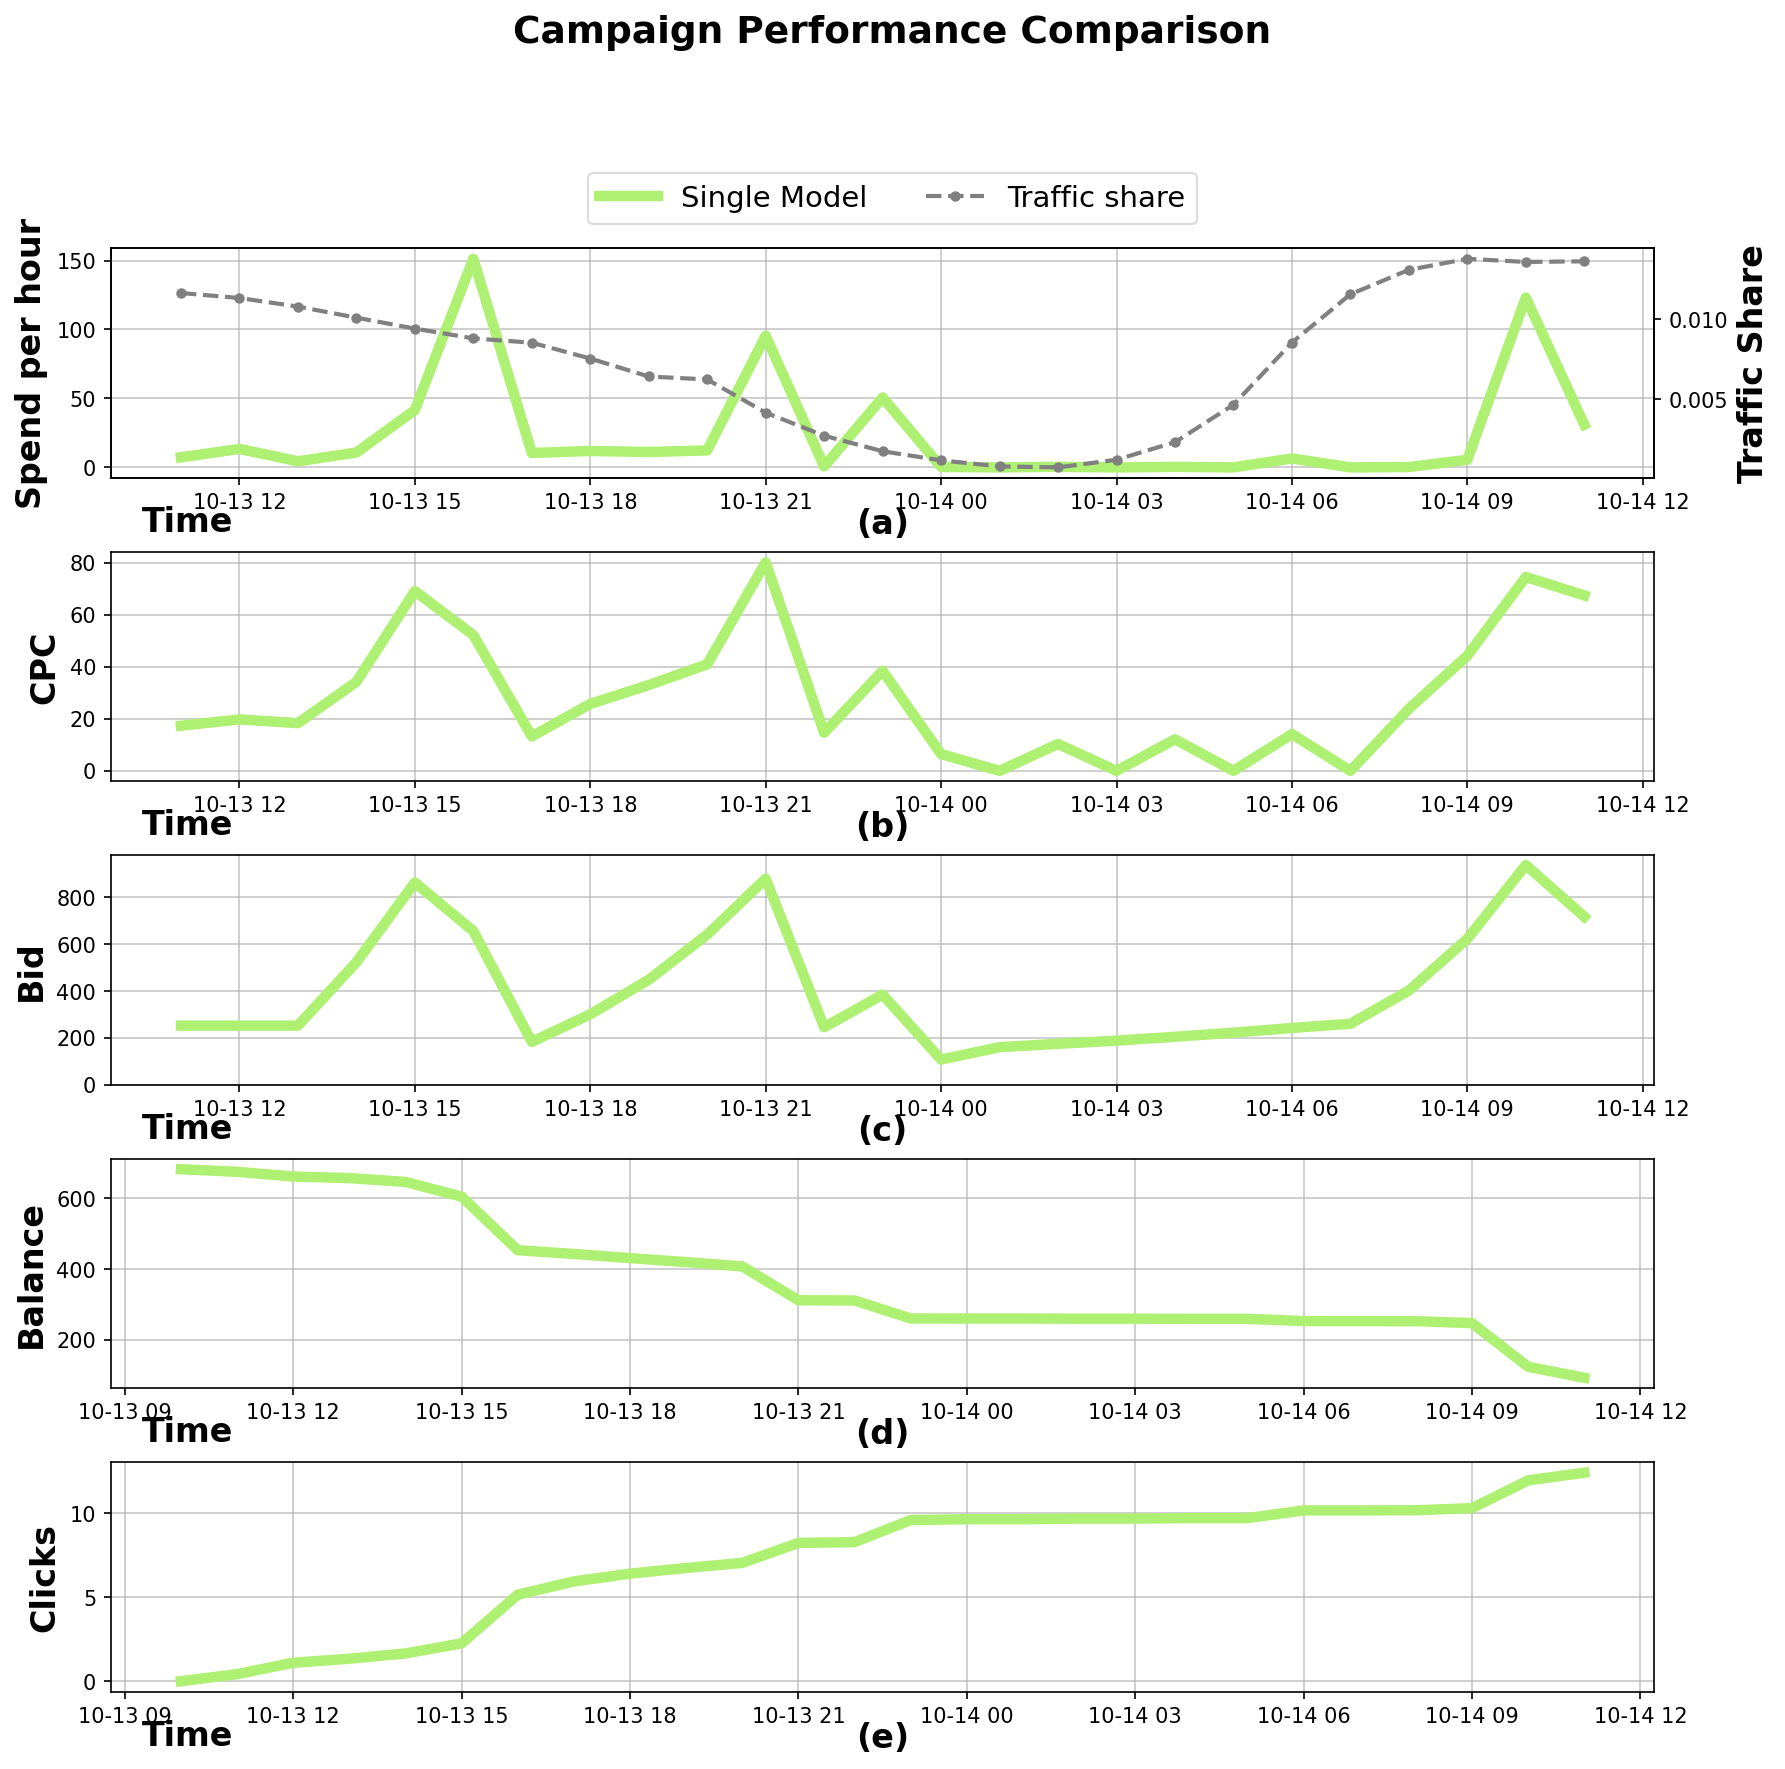

In [21]:
fig = plot_history_article(viz_data_ta_pid)

## M-PID Bidder

In [22]:
# refreshing Campaign
campaign_example = Campaign(
    item_id=campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  681.6
Length hours  24


In [23]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=MPIDBidder(),
    stats_file=campaign_stats,
    auction_mode=auction_mode,
)

In [24]:
df = simulation_history.to_data_frame()
viz_data_m_pid = data_prep_vis(df)
df.head(10)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-13 11:00:00,529574400,529572969,529659369,72791422,681.600000,681.6,0.000000,0.000000,14.8,641780,641470,1.2,573,529570800,0,0,0.000000,0.000000,0.011620,0.011620,14.779531,0.000000
1,1986-10-13 12:00:00,529578000,529572969,529659369,72791422,681.599605,681.6,0.000943,0.000049,8.0,641780,641470,1.2,573,529574400,0,0,0.000395,0.000943,0.011307,0.022927,11.405352,0.418493
2,1986-10-13 13:00:00,529581600,529572969,529659369,72791422,681.534687,681.6,0.049560,0.002897,22.8,641780,641470,1.2,573,529578000,0,0,0.064918,0.048616,0.010773,0.033700,17.149703,1.335316
3,1986-10-13 14:00:00,529585200,529572969,529659369,72791422,681.334897,681.6,0.151682,0.009469,30.4,641780,641470,1.2,573,529581600,0,0,0.199790,0.102122,0.010081,0.043781,18.727586,1.956393
4,1986-10-13 15:00:00,529588800,529572969,529659369,72791422,681.288244,681.6,0.170245,0.010696,38.0,641780,641470,1.2,573,529585200,0,0,0.046653,0.018563,0.009396,0.053177,19.951487,2.513198
5,1986-10-13 16:00:00,529592400,529572969,529659369,72791422,680.537330,681.6,0.428885,0.027164,45.6,641780,641470,1.2,573,529588800,0,0,0.750914,0.258640,0.008786,0.061963,20.951487,2.903316
6,1986-10-13 17:00:00,529596000,529572969,529659369,72791422,680.180192,681.6,0.523603,0.033877,53.2,641780,641470,1.2,573,529592400,0,0,0.357138,0.094719,0.008514,0.070477,21.796975,3.770514
7,1986-10-13 18:00:00,529599600,529572969,529659369,72791422,679.848644,681.6,0.594552,0.039330,60.8,641780,641470,1.2,573,529596000,0,0,0.331548,0.070948,0.007527,0.078004,22.529370,4.673105
8,1986-10-13 19:00:00,529603200,529572969,529659369,72791422,679.409007,681.6,0.697997,0.045757,68.4,641780,641470,1.2,573,529599600,0,0,0.439637,0.103445,0.006405,0.084409,23.175388,4.249951
9,1986-10-13 20:00:00,529606800,529572969,529659369,72791422,678.826676,681.6,0.818915,0.053420,76.0,641780,641470,1.2,573,529603200,0,0,0.582331,0.120919,0.006219,0.090628,23.753271,4.815889


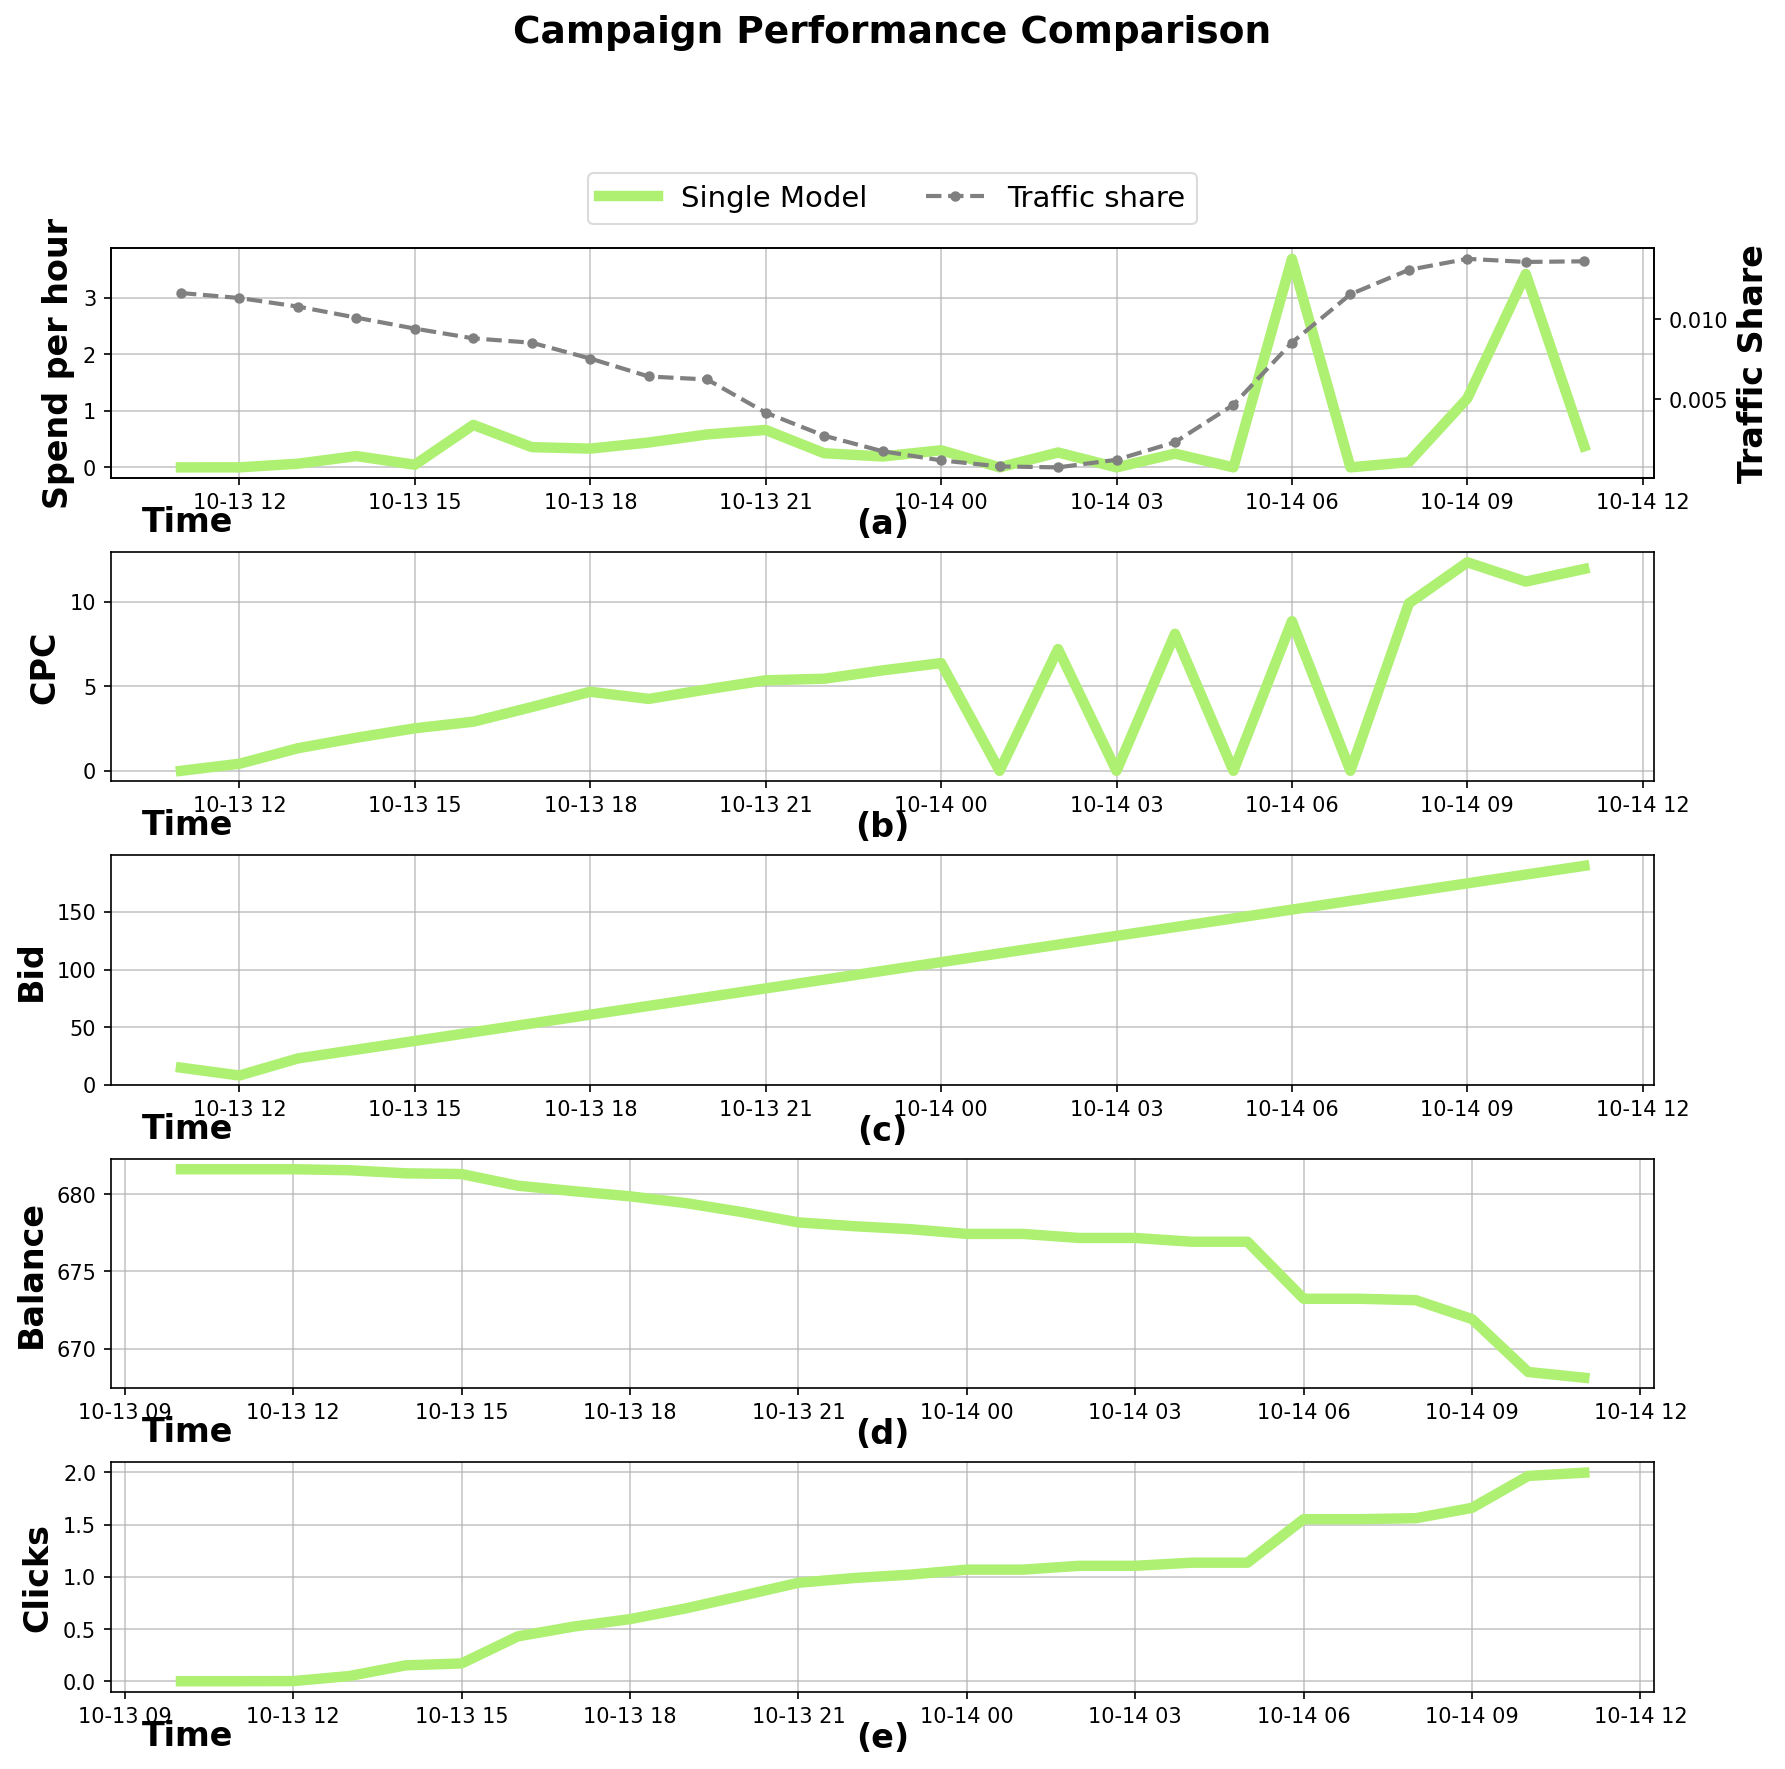

In [25]:
fig = plot_history_article(viz_data_m_pid)

In [26]:
# refreshing Campaign
campaign_example = Campaign(
    item_id=campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)
print("Budget ", campaign_data['auction_budget']) 
print("Length hours ", (campaign_data['campaign_end'] - campaign_data['campaign_start']) // 3600)

Budget  681.6
Length hours  24


In [27]:
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=BROI(),
    stats_file=campaign_stats,
    auction_mode=auction_mode,
)

In [28]:
df = simulation_history.to_data_frame()
viz_data_broi = data_prep_vis(df)
df.head(10)

,curr_time,curr_timestamp,campaign_start_time,campaign_end_time,campaign_id,balance,initial_balance,clicks,contacts,bid,loc_id,region_id,logical_category,microcat_ext,prev_timestamp,desired_clicks,desired_time,spend_history,clicks_history,tr_share,tr_share_cs,price_bin,cpc
0,1986-10-13 11:00:00,529574400,529572969,529659369,72791422,681.600000,681.6,0.000000,0.000000,6.191736,641780,641470,1.2,573,529570800,0,0,0.000000,0.000000,0.011620,0.011620,10.0,0.000000
1,1986-10-13 12:00:00,529578000,529572969,529659369,72791422,681.600000,681.6,0.000000,0.000000,6.191736,641780,641470,1.2,573,529574400,0,0,0.000000,0.000000,0.011307,0.022927,10.0,0.000000
2,1986-10-13 13:00:00,529581600,529572969,529659369,72791422,681.599634,681.6,0.000982,0.000059,6.191736,641780,641470,1.2,573,529578000,0,0,0.000366,0.000982,0.010773,0.033700,10.0,0.372680
3,1986-10-13 14:00:00,529585200,529572969,529659369,72791422,681.598902,681.6,0.002946,0.000177,6.191736,641780,641470,1.2,573,529581600,0,0,0.000732,0.001964,0.010081,0.043781,10.0,0.372680
4,1986-10-13 15:00:00,529588800,529572969,529659369,72791422,681.598902,681.6,0.002946,0.000177,6.191736,641780,641470,1.2,573,529585200,0,0,0.000000,0.000000,0.009396,0.053177,10.0,0.000000
5,1986-10-13 16:00:00,529592400,529572969,529659369,72791422,681.530822,681.6,0.167543,0.011173,6.191736,641780,641470,1.2,573,529588800,0,0,0.068080,0.164597,0.008786,0.061963,10.0,0.413617
6,1986-10-13 17:00:00,529596000,529572969,529659369,72791422,681.512524,681.6,0.210167,0.014128,6.191736,641780,641470,1.2,573,529592400,0,0,0.018298,0.042624,0.008514,0.070477,10.0,0.429288
7,1986-10-13 18:00:00,529599600,529572969,529659369,72791422,681.502018,681.6,0.232909,0.015825,6.191736,641780,641470,1.2,573,529596000,0,0,0.010506,0.022742,0.007527,0.078004,10.0,0.461944
8,1986-10-13 19:00:00,529603200,529572969,529659369,72791422,681.490497,681.6,0.261037,0.017685,6.191736,641780,641470,1.2,573,529599600,0,0,0.011521,0.028128,0.006405,0.084409,10.0,0.409599
9,1986-10-13 20:00:00,529606800,529572969,529659369,72791422,681.490126,681.6,0.262019,0.017745,6.191736,641780,641470,1.2,573,529603200,0,0,0.000372,0.000983,0.006219,0.090628,10.0,0.378417


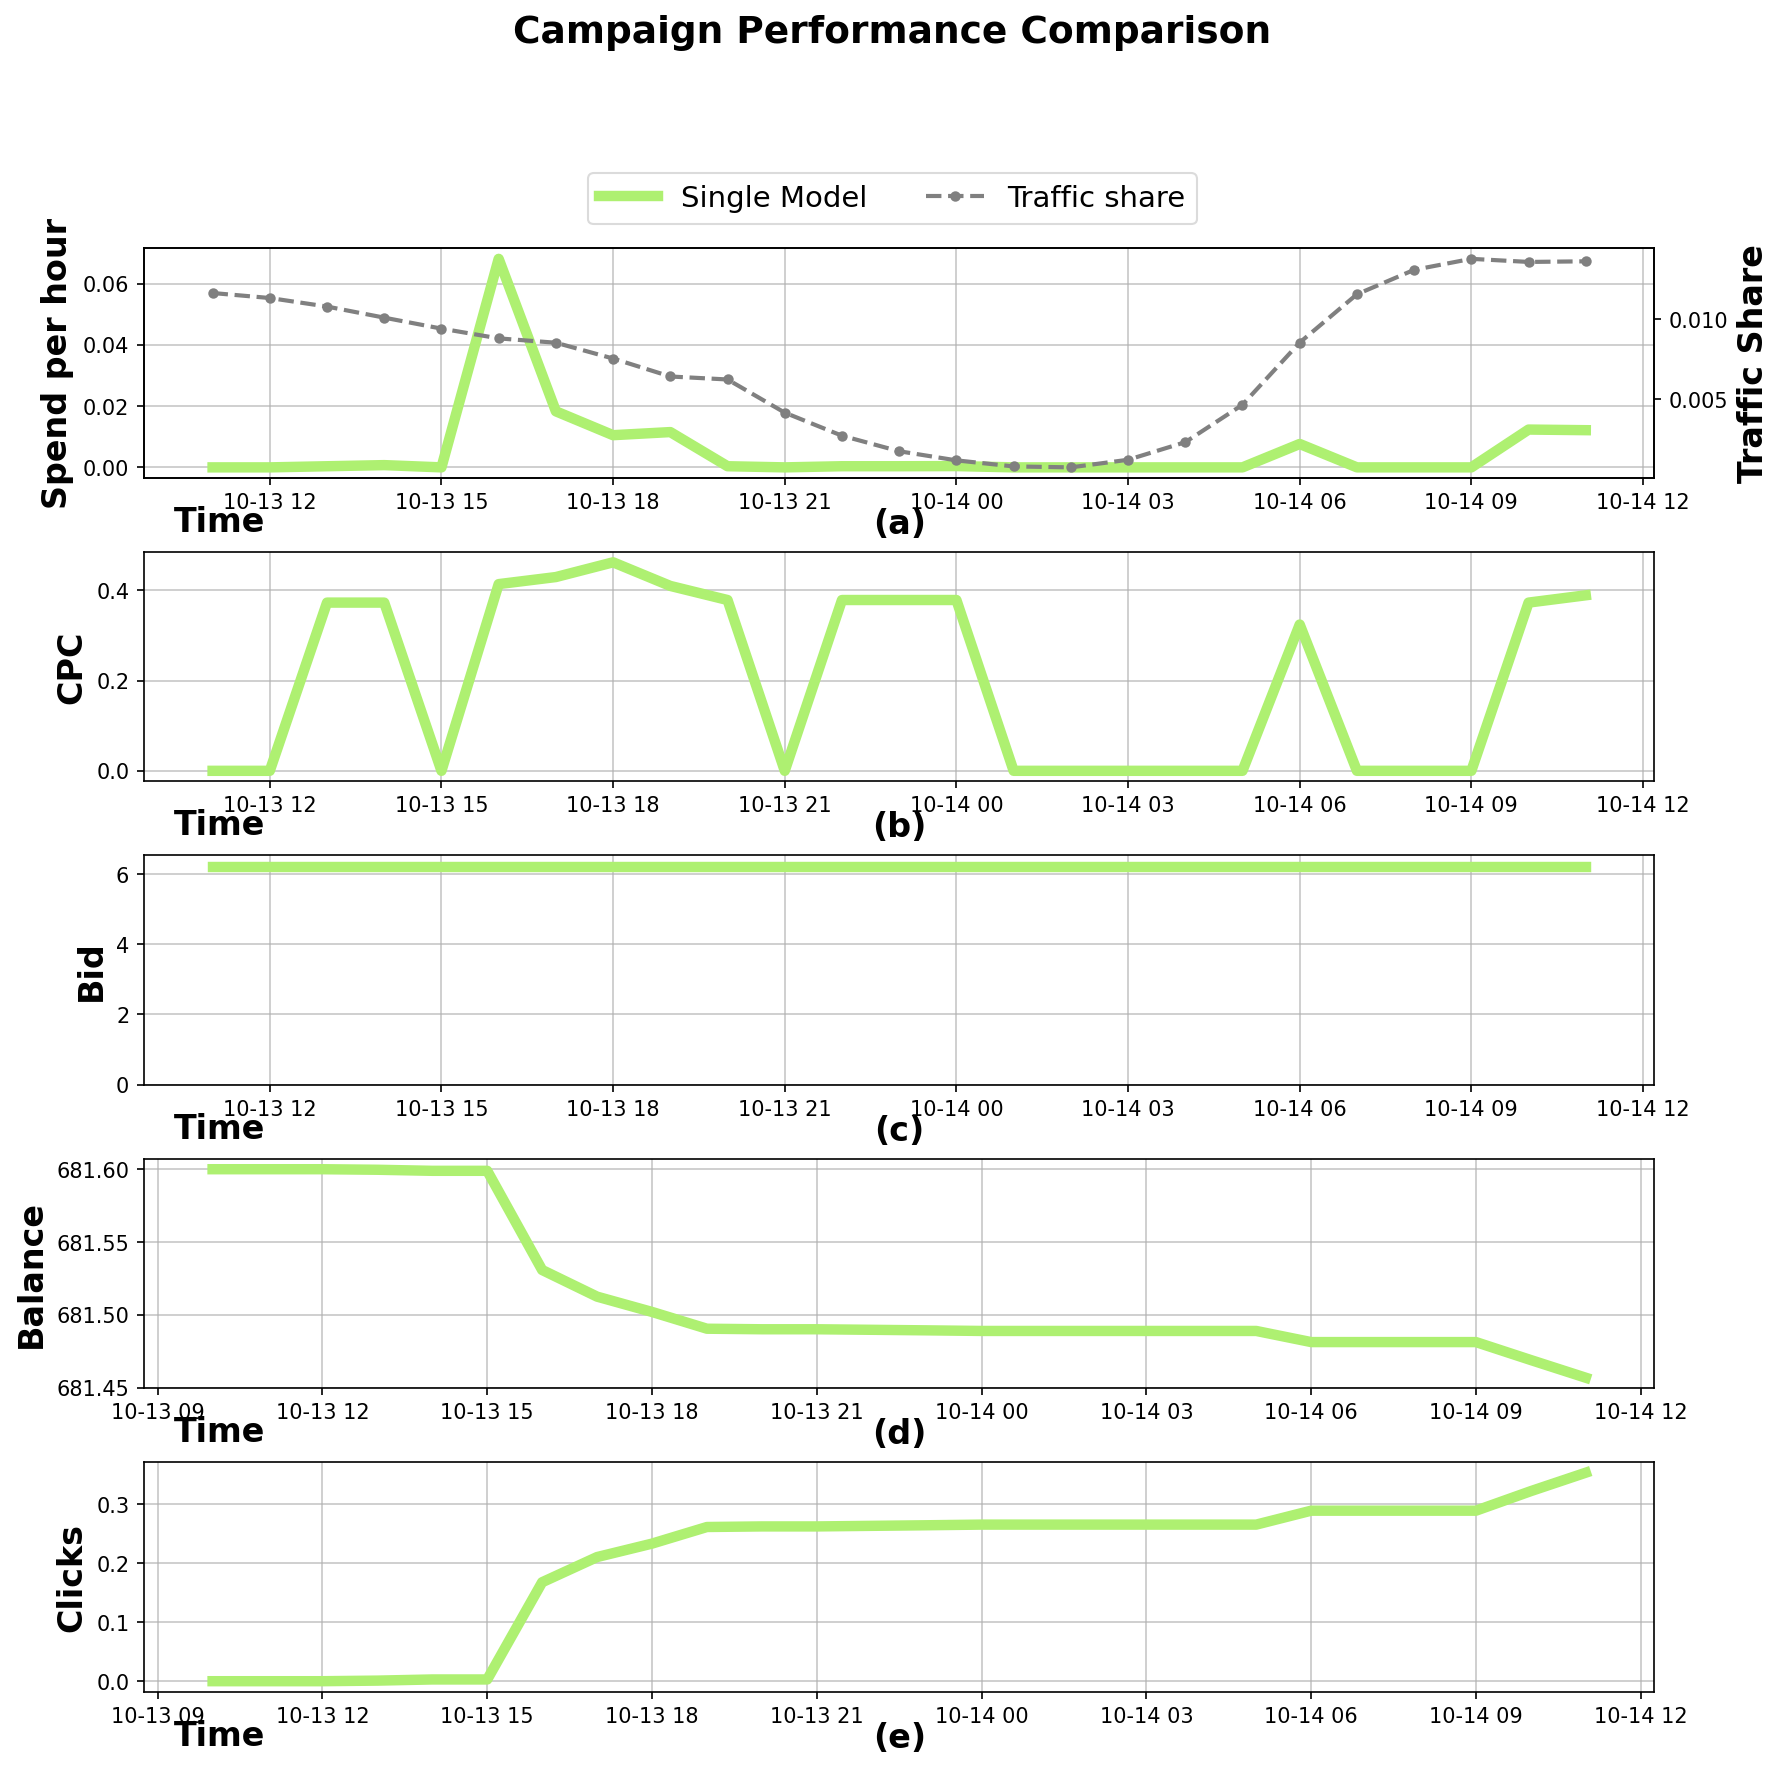

In [29]:
fig = plot_history_article(viz_data_broi)

## You may also compare the performance of all the baselines:

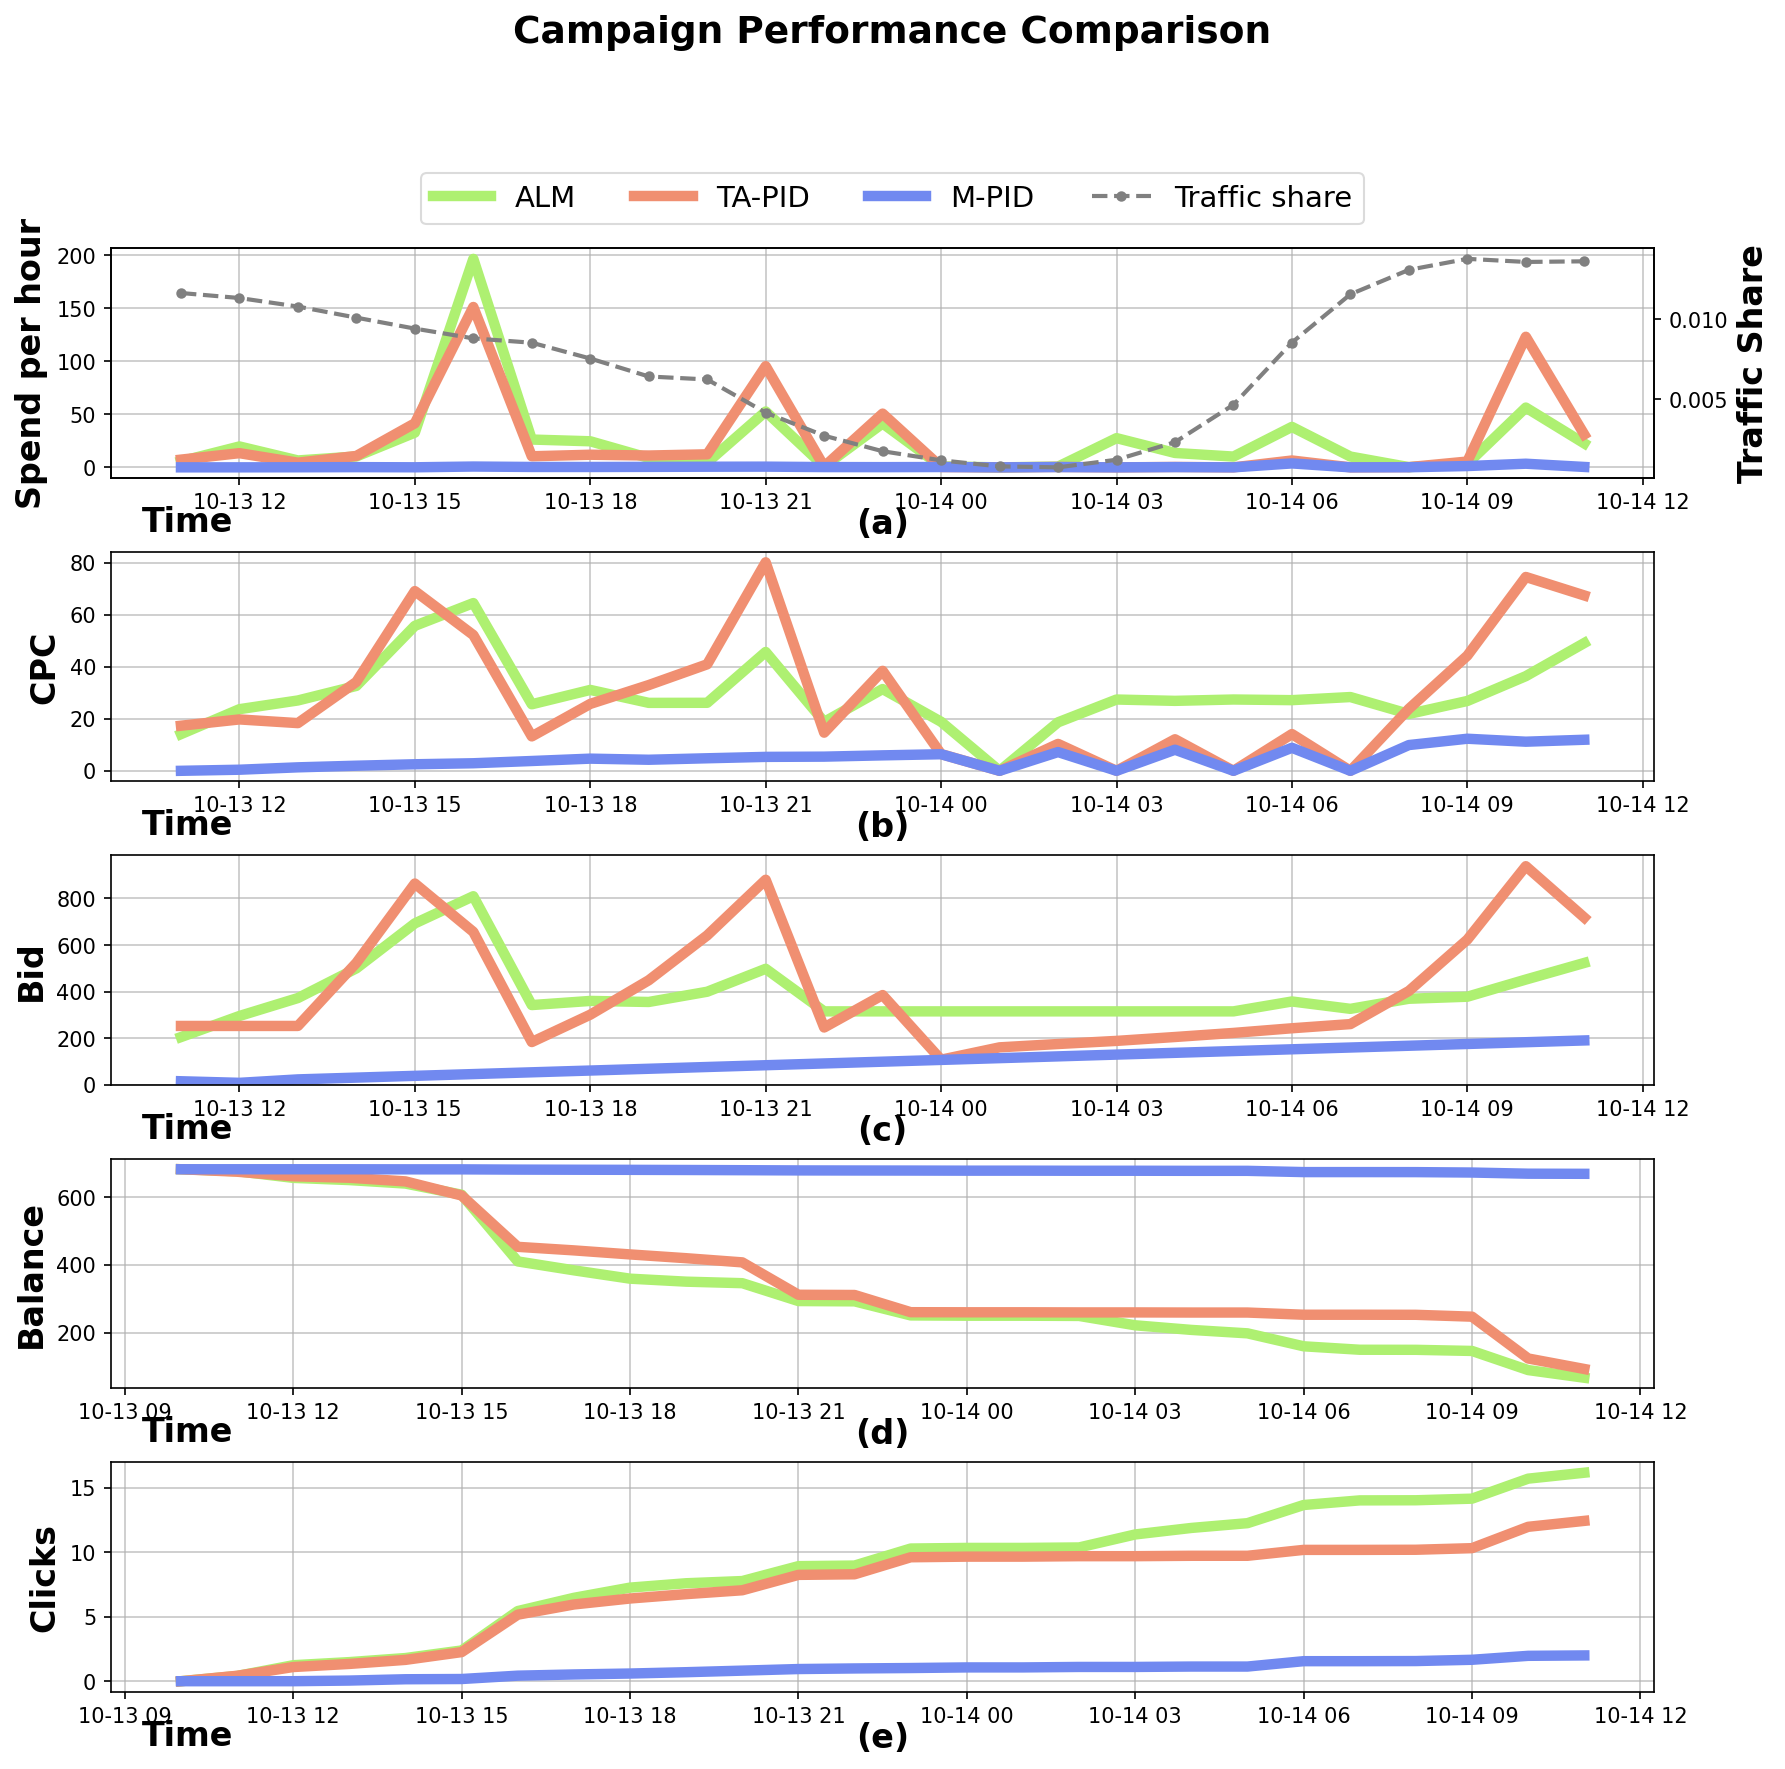

In [30]:
f = plot_history_article([viz_data_linear, viz_data_ta_pid, viz_data_m_pid], single_plot=False)

# Metrics

In [31]:
best_metrics = np.ones((3, 3)) * 100000

In [32]:
best_metrics

array([[100000., 100000., 100000.],
       [100000., 100000., 100000.],
       [100000., 100000., 100000.]])

### Mean 

## Linear Bidder

In [33]:
def objective_linear(trial, metric='RMSE_T', auction_mode='FPA'):
    coef = trial.suggest_float('coef', 0.001, 0.999, log=True) # Cold start coefficient
    lower_clip = trial.suggest_int('lower_clip', 1, 20, log=True)
    upper_clip = trial.suggest_int('upper_clip', 1, 20, log=True)
    factor = trial.suggest_float('factor', 1.1, 10.0, log=True)
   
    res = autobidder_check(
        bidder=LinearBidder,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "cold_start_coef": coef,
            "lower_clip": lower_clip,
            "upper_clip": upper_clip,
            "factor": factor # slope
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
      
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 

    
def opt_search_linear(n_trials=100, metric='RMSE_T', auction_mode='FPA'):
    # Create pruner
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10,
        interval_steps=1
    )

    # Create study with pruner
    study = optuna.create_study(
        direction='maximize' if (metric == 'MCR') else 'minimize',
        pruner=pruner
    )

    # Optimization
    study.optimize(
        partial(objective_linear, metric=metric, auction_mode=auction_mode),
        n_trials=n_trials,
        catch=(Exception,)
    )

    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/linear_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [34]:
n = 10
metric = 'RMSE_T' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_linear(n, metric, auction_mode)

[I 2026-02-05 09:49:37,564] A new study created in memory with name: no-name-06f21c7c-d272-4bcb-b5db-a606069f3a06
[I 2026-02-05 09:49:38,942] Trial 0 finished with value: 0.8498210564256413 and parameters: {'coef': 0.006205435721715632, 'lower_clip': 5, 'upper_clip': 1, 'factor': 1.583067486753153}. Best is trial 0 with value: 0.8498210564256413.


CPC_REL: 7.324516233780282, rmse: 0.8498210564256413, SCR: 206.7392515728758


[I 2026-02-05 09:49:40,037] Trial 1 finished with value: 45.01822989070164 and parameters: {'coef': 0.29119999685227954, 'lower_clip': 1, 'upper_clip': 9, 'factor': 9.830830592692042}. Best is trial 0 with value: 0.8498210564256413.


CPC_REL: 116.82046469784936, rmse: 45.01822989070164, SCR: 11.410325619555474


[I 2026-02-05 09:49:41,491] Trial 2 finished with value: 3.86644502296852 and parameters: {'coef': 0.06393844736932662, 'lower_clip': 8, 'upper_clip': 2, 'factor': 5.5559626917469656}. Best is trial 0 with value: 0.8498210564256413.


...

[I 2026-02-05 09:49:49,424] Trial 8 finished with value: 19.408559740139964 and parameters: {'coef': 0.12433211506386482, 'lower_clip': 20, 'upper_clip': 14, 'factor': 5.664553169370882}. Best is trial 5 with value: 0.6414520329319259.


CPC_REL: 64.38777440864281, rmse: 19.408559740139964, SCR: 16.01214115620258


[I 2026-02-05 09:49:50,537] Trial 9 finished with value: 12.787875198842299 and parameters: {'coef': 0.7626437159323107, 'lower_clip': 5, 'upper_clip': 3, 'factor': 9.945228025111945}. Best is trial 5 with value: 0.6414520329319259.


CPC_REL: 67.06530921909312, rmse: 12.787875198842299, SCR: 17.783182400984977
Best trial:
  Value: 0.6414520329319259
  Params: 
    coef: 0.039523442953042526
    lower_clip: 7
    upper_clip: 1
    factor: 3.2371891063722287


FileNotFoundError: [Errno 2] No such file or directory: 'best_params/linear_rmse_t_FPA.pkl'

In [ ]:
n = 10
metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_linear(n, metric, auction_mode)

In [ ]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_linear(n, metric, auction_mode)

## TA-PID Bidder

In [ ]:
def objective_tapid(trial, metric='RMSE_T', auction_mode='FPA'):
    k_p1 = trial.suggest_float('k_p1', 1e-4, 1, log=True)
    k_i1 = trial.suggest_float('k_i1', 1e-4, 1, log=True)
    k_d1 = trial.suggest_float('k_d1', 1e-4, 1, log=True)
    coef = trial.suggest_float('coef', 0.1, 0.9, log=True) # Cold start coefficient
    k_dict = {
        'k_p': k_p1,
        'k_i': k_i1,
        'k_d': k_d1
    }
   
    res = autobidder_check(
        bidder=TAPIDBidder,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "k_dict": k_dict, 
            'cold_start_coef': coef,
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
        print(f'PROBLEMS???{abs(1 - res["score"][0])}')
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 

def opt_search_tapid(n_trials, metric, auction_mode='FPA'):
    # if metric == 'RMSE_T':
    study = optuna.create_study(
        direction='maximize' if metric == 'MCR' else 'minimize'
    )
    # elif metric == 'MCR':
    #     study = optuna.create_study(direction='maximize')
    study.optimize(partial(objective_tapid, metric=metric, auction_mode=auction_mode), n_trials=n_trials)

    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/ta_pid_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [ ]:
n = 10
metric = 'RMSE_T' # for Mean Click Ratio use 'MCR'
study_ta_pid = opt_search_tapid(n, metric, auction_mode)

In [ ]:
n = 10
metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
study_ta_pid = opt_search_tapid(n, metric, auction_mode)

In [ ]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_tapid(n, metric, auction_mode)

In [ ]:
best_metrics

## M-PID Bidder

In [ ]:
def objective_mpid(trial, metric='RMSE_T', auction_mode='FPA'):
    k_p1 = trial.suggest_float('k_p1', 1e-4, 1, log=True)
    k_p2 = trial.suggest_float('k_p2', 1e-4, 1, log=True)
    k_i1 = trial.suggest_float('k_i1', 1e-4, 1, log=True)
    k_i2 = trial.suggest_float('k_i2', 1e-4, 1, log=True)
    k_d1 = trial.suggest_float('k_d1', 1e-4, 1, log=True)
    k_d2 = trial.suggest_float('k_d2', 1e-4, 1, log=True)
    alpha = trial.suggest_float('alpha', 0.1, 0.9, log=True)
    beta = trial.suggest_float('beta', 0.1, 0.9, log=True)
    coef = trial.suggest_float('coef', 0.1, 0.9, log=True) # Cold start coefficient
    lower_clip = trial.suggest_float('lower_clip', 0.1, 0.9, log=True)
    upper_clip = trial.suggest_float('upper_clip', 1.5, 10, log=True)
    bid_factor = trial.suggest_float('bid_factor', 0.5, 20.0, log=True)
    temp_coef = 1.0
    
    k_dict = {
        'k_p': (k_p1, k_p2),
        'k_i': (k_i1, k_i2),
        'k_d': (k_d1, k_d2)
    }
   
    res = autobidder_check(
        bidder=MPIDBidder,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "k_dict": k_dict, 
            "correction": [alpha, beta],
            'cold_start_coef': coef,
            'lower_clip': lower_clip, 
            'upper_clip': upper_clip, 
            'bid_factor': bid_factor,
            #'temp_constr': temp_constr,
            'temp_coef': temp_coef},
        auction_mode=auction_mode,
    )
    print(f"rel_cpc: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[2, 0] = min(best_metrics[2, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[2, 1] = min(best_metrics[2, 1], res['score'][0])
        return res['score'][0]
    elif metric == 'weighted_sum':
        best_metrics[2, 2] = min(best_metrics[2, 2], res['score'][2])
        return res['score'][2]

def opt_search_mpid(n_trials, metric='RMSE_T', auction_mode='FPA'):
    study = optuna.create_study(direction='maximize' if metric == 'MCR' else 'minimize')
    study.optimize(partial(objective_mpid, metric=metric, auction_mode=auction_mode), n_trials=n_trials, n_jobs=1)
    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [ ]:
def objective_mpid(trial, metric='RMSE_T', auction_mode='FPA'):
    k_p1 = trial.suggest_float('k_p1', 1e-4, 1, log=True)
    k_p2 = trial.suggest_float('k_p2', 1e-4, 1, log=True)
    k_i1 = trial.suggest_float('k_i1', 1e-4, 1, log=True)
    k_i2 = trial.suggest_float('k_i2', 1e-4, 1, log=True)
    k_d1 = trial.suggest_float('k_d1', 1e-4, 1, log=True)
    k_d2 = trial.suggest_float('k_d2', 1e-4, 1, log=True)
    alpha = trial.suggest_float('alpha', 0.1, 0.9, log=True)
    beta = trial.suggest_float('beta', 0.1, 0.9, log=True)
    coef = trial.suggest_float('coef', 0.1, 0.9, log=True) # Cold start coefficient
    lower_clip = trial.suggest_float('lower_clip', 0.1, 0.9, log=True)
    upper_clip = trial.suggest_float('upper_clip', 1.5, 10, log=True)
    bid_factor = trial.suggest_float('bid_factor', 0.5, 20.0, log=True)
    
    k_dict = {
        'k_p': (k_p1, k_p2),
        'k_i': (k_i1, k_i2),
        'k_d': (k_d1, k_d2)
    }
   
    res = autobidder_check(
        bidder=MPIDBidder,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "k_dict": k_dict, 
            "correction": [alpha, beta],
            'cold_start_coef': coef,
            'lower_clip': lower_clip, 
            'upper_clip': upper_clip, 
            'bid_factor': bid_factor},
        auction_mode=auction_mode,
    )
    
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    
    if metric == 'RMSE_T':
        best_metrics[2, 0] = min(best_metrics[2, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
       
        
        best_metrics[2, 1] = min(best_metrics[2, 1], res['score'][0])
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[2, 2] = max(best_metrics[2, 2], res['score'][2])
        return res['score'][2]

def opt_search_mpid(n_trials, metric='RMSE_T', auction_mode='FPA'):
    # if metric == 'RMSE_T':
    study = optuna.create_study(direction='maximize' if (metric == 'MCR') else 'minimize')
    # elif metric == 'MCR':
    #     study = optuna.create_study(direction='maximize')
    study.optimize(partial(objective_mpid, metric=metric, auction_mode=auction_mode), n_trials=n_trials, n_jobs=6)

    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [ ]:
n = 10
metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
study_m_pid = opt_search_mpid(n, metric, auction_mode)

In [ ]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_m_pid = opt_search_mpid(n, metric, auction_mode)

In [ ]:
n = 10
metric = 'RMSE_T' # for Mean Click Ratio use 'MCR'
study_m_pid = opt_search_mpid(n, metric, auction_mode)

In [ ]:
print('VCG, RMSE_T| REL_CPC| RMSE_T+REL_CPC: ')
np.set_printoptions(precision=5,suppress=True)
print('Linear', best_metrics[0])
print('TA-PID', best_metrics[1])
print('M-PID', best_metrics[2])

In [ ]:
print('FPA, RMSE_T| REL_CPC| RMSE_T+REL_CPC: ')
np.set_printoptions(precision=5,suppress=True)
print('Linear', best_metrics[0])
print('TA-PID', best_metrics[1])
print('M-PID', best_metrics[2])

# Mystique bidder

In [ ]:
def objective_mystique(trial, metric='RMSE_T', auction_mode='FPA'):
   

    pf0 = trial.suggest_float('pf0', 1, 200, log=True)
    C_max = trial.suggest_float('C_max', 1, 100, log=True)
    C_min = trial.suggest_float('C_min', 1e-4, 1, log=True)
    E_max = trial.suggest_float('E_max', 1, 100, log=True)
    E_gmc = trial.suggest_float('E_gmc', 1, 100, log=True)
   
    res = autobidder_check(
        bidder=Mystique,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            "pf0": pf0, 
            "C_max": C_max,
            'C_min': C_min,
            'E_max': E_max, 
            'E_gmc': E_gmc},
        auction_mode=auction_mode,
    )

    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        return res['score'][1] 
    elif metric == 'CPC_REL':
        return res['score'][0] 
    elif metric == 'MCR':
        return res['score'][2] 

def opt_search_mystique(n_trials, metric='RMSE_T', auction_mode='FPA'): 
    study = optuna.create_study(direction='maximize' if metric == 'MCR' else 'minimize')
    study.optimize(partial(objective_mystique, metric=metric, auction_mode=auction_mode), n_trials=n_trials, n_jobs=6)
    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/mystique_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [ ]:
n = 10
metric = 'RMSE_T' # for Mean Click Ratio use 'MCR'
study_mystique = opt_search_mystique(n, metric,  auction_mode)

In [ ]:
n = 10
metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
study_mystique = opt_search_mystique(n, metric,  auction_mode)

In [ ]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_mystique = opt_search_mystique(n, metric, auction_mode)

### BROI

In [ ]:
def objective_broi(trial, metric='RMSE_T', auction_mode='FPA'):
    ro = trial.suggest_float('ro', 0.01, 200, log=True)
    v_bar = trial.suggest_float('v_bar', 0.01, 200, log=True)
   
    res = autobidder_check(
        bidder=BROI,
        params={
            "input_campaigns": campaigns_path,
            "input_stats": stats_path,
            'ro': ro,
            'v_bar': v_bar
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = max(best_metrics[0, 1], res['score'][0])
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2]
    
def opt_search_broi(n_trials=100, metric='RMSE_T', auction_mode='FPA'):
    # Create pruner
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10,
        interval_steps=1
    )
    # Create study with pruner
    study = optuna.create_study(
        direction='maximize' if (metric == 'MCR') else 'minimize',
        pruner=pruner,
        storage=f'sqlite:///broi_{metric}.db'
    )
    # Optimization
    study.optimize(
        partial(objective_broi, metric=metric, auction_mode=auction_mode),
        n_trials=n_trials,
        catch=(Exception,)
    )
    print('Best trial:')
    trial = study.best_trial
    print(f'  Value: {trial.value}')
    print('  Params: ')
    dict_path = f'best_params/broi_{metric.lower()}_{auction_mode}.pkl'
    params_dict = dict()
    for key, value in trial.params.items():
        print(f'    {key}: {value}')
        params_dict[key] = value
    # save the best params to the file
    with open(dict_path, 'wb') as f:
        pickle.dump(params_dict, f)
    return study

In [ ]:
n = 10
metric = 'CPC_REL' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_broi(n, metric, auction_mode)

In [ ]:
n = 10
metric = 'MCR' # for Mean Click Ratio use 'MCR'
study_linear = opt_search_broi(n, metric, auction_mode)



# Evaluation with the best params

In [ ]:
campaigns_path_test = f"../data/{auction_mode.lower()}/campaigns_{auction_mode.lower()}_filtered_test_final.csv"
stats_path_test = f"../data/{auction_mode.lower()}/stats_{auction_mode.lower()}_filtered_test_final.csv"

In [ ]:
best_metrics_eval = np.ones((3, 3)) * 100000

### Linear Bidder

In [ ]:
def eval_linear(params_dict, metric='RMSE_T', auction_mode='FPA'):
    res = autobidder_check(
        bidder=LinearBidder,
        params={
            "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            "cold_start_coef": params_dict['coef'],
            "lower_clip": params_dict['lower_clip'],
            "upper_clip": params_dict['upper_clip'],
            "factor": params_dict['factor']
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
        print(f'PROBLEMS???{abs(1 - res["score"][0])}')
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 
        


In [ ]:
campaigns = pd.read_csv(campaigns_path_test)
stats = pd.read_csv(stats_path_test)

In [ ]:
%%time
metric = 'RMSE_T'
dict_path = f'best_params/linear_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_linear(params, metric, auction_mode)

In [ ]:
%%time
metric = 'CPC_REL'
dict_path = f'best_params/linear_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_linear(params, metric, auction_mode)

In [ ]:
%%time
metric = 'MCR'
dict_path = f'best_params/linear_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_linear(params, metric, auction_mode)

### TA-PID

In [ ]:
def eval_tapid(params, metric='RMSE_T', auction_mode='FPA'):
    k_dict = {
        'k_p': params['k_p1'],
        'k_i': params['k_i1'],
        'k_d': params['k_d1']
    }
   
    res = autobidder_check(
        bidder=TAPIDBidder,
        params={
            "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            "k_dict": k_dict, 
            'cold_start_coef': params['coef'],
        },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
        print(f'PROBLEMS???{abs(1 - res["score"][0])}')
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 

In [ ]:
%%time
metric = 'RMSE_T'
dict_path = f'best_params/ta_pid_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_tapid(params, metric, auction_mode)

In [ ]:
%%time
metric = 'CPC_REL'
dict_path = f'best_params/ta_pid_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_tapid(params, metric, auction_mode)

In [ ]:
%%time
metric = 'MCR'
dict_path = f'best_params/ta_pid_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_tapid(params, metric, auction_mode)

### M-PID

In [ ]:
%%time

params = {
    'k_p1': 0.0009872512245452012,
    'k_p2': 0.18897715248785318,
    'k_i1': 0.9966528621547841,
    'k_i2': 0.0003253464269231336,
    'k_d1': 0.07272030450279275,
    'k_d2': 0.002192881493259258,
    'alpha': 0.7071773265998677,
    'beta': 0.17578463114240267,
    'coef': 0.16586633242779408,
    'lower_clip': 0.23922786884323818,
    'upper_clip': 1.5030018770923117,
    'bid_factor': 18.942084662162305
    
}
with open(dict_path, 'wb') as f:
    pickle.dump(params, f)

In [ ]:
def eval_mpid(params, metric='RMSE_T', auction_mode='FPA'):    
    k_dict = {
        'k_p': (params['k_p1'], params['k_p2']),
        'k_i': (params['k_i1'], params['k_i2']),
        'k_d': (params['k_d1'], params['k_d2'])
    }
   
    res = autobidder_check(
        bidder=MPIDBidder,
        params={
            "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            "k_dict": k_dict, 
            "correction": [params['alpha'], params['beta']],
            'cold_start_coef': params['coef'],
            'lower_clip': params['lower_clip'], 
            'upper_clip': params['upper_clip'], 
            'bid_factor': params['bid_factor'],},
            #'temp_coef': params['temp_coef'],},
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = max(best_metrics[0, 1], res['score'][0])
        
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 



In [ ]:
%%time
metric = 'CPC_REL'
dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_mpid(params, metric, auction_mode)

In [ ]:
%%time
metric = 'RMSE_T'
dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_mpid(params, metric, auction_mode)

In [ ]:
%%time
metric = 'MCR'
dict_path = f'best_params/m_pid_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_mpid(params, metric, auction_mode)

In [ ]:
print('VCG, RMSE_T| REL_CPC| RMSE_T+REL_CPC: ')
np.set_printoptions(precision=5,suppress=True)
print('Linear', best_metrics_eval[0])
print('TA-PID', best_metrics_eval[1])
print('M-PID', best_metrics_eval[2])

In [ ]:
print('FPA, RMSE_T| REL_CPC| RMSE_T+REL_CPC: ')
np.set_printoptions(precision=5,suppress=True)
print('Linear', best_metrics_eval[0])
print('TA-PID', best_metrics_eval[1])
print('M-PID', best_metrics_eval[2])

#__Mystique__



In [ ]:
def eval_mystique(params, metric='RMSE_T', auction_mode='FPA'):
   
   
    res = autobidder_check(
        bidder=Mystique,
       params = {
           "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            "pf0": params['pf0'],
            "C_max": params['C_max'],
            "C_min": params['C_min'],
            "E_max": params['E_max'],
            "E_gmc": params['E_gmc']
    },
        auction_mode=auction_mode,
    )
    print(f"rel_cpc: {res['score'][0]}, rmse: {res['score'][1]}, mcr: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics_eval[1, 0] = min(best_metrics_eval[1, 0], res['score'][1])
        return res['score'][1]  
    elif metric == 'CPC_REL':
        best_metrics_eval[1, 1] = min(best_metrics_eval[1, 1], res['score'][0])
        return res['score'][0]
    elif metric == 'MCR':
        best_metrics_eval[1, 2] = max(best_metrics_eval[1, 2], res['score'][2])
        return res['score'][2]
    else:
        print('problems')

In [ ]:
%%time
metric = 'RMSE_T'
dict_path = f'best_params/mystique_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_mystique(params, metric, auction_mode)

In [ ]:
%%time
metric = 'CPC_REL'
dict_path = f'best_params/mystique_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_mystique(params, metric, auction_mode)

In [ ]:
%%time
metric = 'MCR'
dict_path = f'best_params/mystique_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_mystique(params, metric, auction_mode)

### BROI

In [ ]:
def eval_broi(params, metric='RMSE_T', auction_mode='FPA'):
   
   
    res = autobidder_check(
        bidder=BROI,
       params = {
            "input_campaigns": campaigns_path_test,
            "input_stats": stats_path_test,
            #'theta': params['theta'],
            'ro': params['ro'],
            'v_bar': params['v_bar']
    },
        auction_mode=auction_mode,
    )
    print(f"CPC_REL: {res['score'][0]}, rmse: {res['score'][1]}, SCR: {res['score'][2]}")
    if metric == 'RMSE_T':
        best_metrics[0, 0] = min(best_metrics[0, 0], res['score'][1])
        return res['score'][1] 
    elif metric == 'CPC_REL':
        best_metrics[0, 1] = min(best_metrics[0, 1], res['score'][0])
        
        return res['score'][0] 
    elif metric == 'MCR':
        best_metrics[0, 2] = max(best_metrics[0, 2], res['score'][2])
        return res['score'][2] 

In [ ]:
%%time
metric = 'MCR'
dict_path = f'best_params/broi_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_broi(params, metric, auction_mode)

In [ ]:
%%time
metric = 'CPC_REL'
dict_path = f'best_params/broi_{metric.lower()}_{auction_mode}.pkl'
with open(dict_path, 'rb') as f:
    params = pickle.load(f)

eval_broi(params, metric, auction_mode)